# Tarea 3 Algoritmos de Aprendizaje Supervisado #
## Dataset Regresión Logística – Heart Disease Cleveland UCI ##
### Jaime Daniel Cerón Rosales ###
### UNAD - 2025 ###

## OBJETIVOS ##
- Aplicar técnicas de clasificación basadas en regresión logística para predecir si un paciente tiene enfermedades cardiacas.

- Crear un modelo de regresión logística con una búsqueda exhaustiva de hiperparámetros, y evaluar el mejor modelo resultante con métricas de desempeño.

## DATOS ##
Los datos son obtenidos de https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data  El archivo en el cual esta la información es:  heart_cleveland_upload con  extensión .cvs No se realiza ninguna modificación adicional.

##  DESARROLLO
A continuación se realizará las actividades propuestas para la entrega de la Tarea 3.

### 1. Exploración y Perfilamiento de datos

**Cargue de librerias y datos**

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

**Lectura de datos**

In [2]:
data_raw = pd.read_csv('/content/heart_cleveland_upload.csv') # Ruta de acceso a los datos
data_raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


**Dimensiones e información del DataFrame**

In [4]:
#Dimensión del DataFrame
data_raw.shape

(297, 14)

In [5]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
data_raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [7]:
print(data_raw['condition'].value_counts())

condition
0    160
1    137
Name: count, dtype: int64


**Datos ausentes y duplicados** Para el perfilamiento de datos se examina la calidad de los datos por medio de los valores faltantes y duplicados

In [8]:
data_raw.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
data_raw.duplicated().sum()

np.int64(0)

Explorando la distribucion de la variable objetivo "condition"

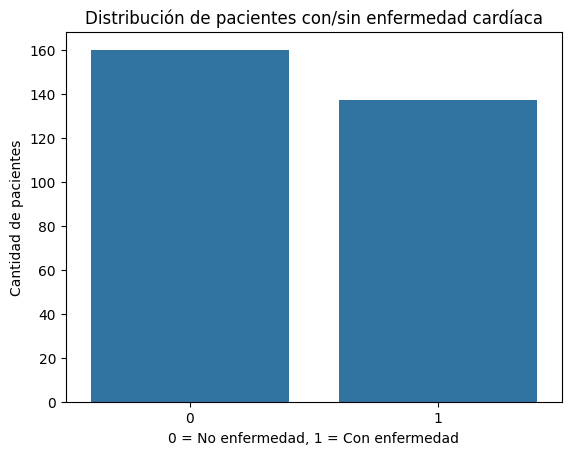

In [11]:
sns.countplot(x='condition', data=data_raw)
plt.title('Distribución de pacientes con/sin enfermedad cardíaca')
plt.xlabel('0 = No enfermedad, 1 = Con enfermedad')
plt.ylabel('Cantidad de pacientes')
plt.show()

- 160 pacientes sin enfermedad cardíaca (clase 0)

- 137 pacientes con enfermedad cardíaca (clase 1)

Esto indica que el dataset está ligeramente desbalanceado, pero no de forma extrema

**Correlación de las variables**

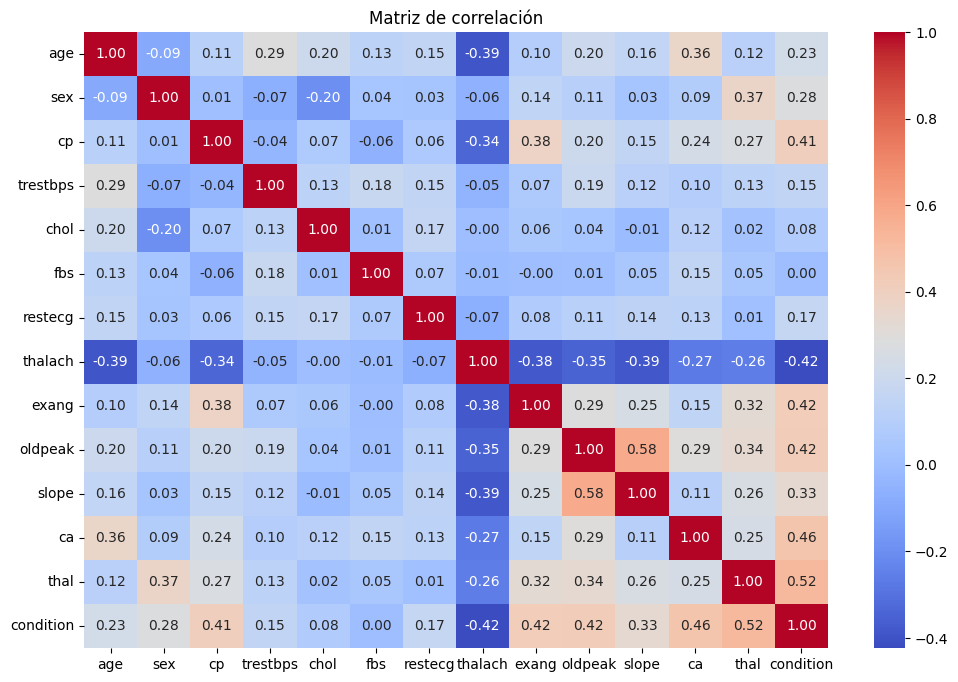

                age       sex        cp  trestbps      chol       fbs  \
age        1.000000 -0.092399  0.110471  0.290476  0.202644  0.132062   
sex       -0.092399  1.000000  0.008908 -0.066340 -0.198089  0.038850   
cp         0.110471  0.008908  1.000000 -0.036980  0.072088 -0.057663   
trestbps   0.290476 -0.066340 -0.036980  1.000000  0.131536  0.180860   
chol       0.202644 -0.198089  0.072088  0.131536  1.000000  0.012708   
fbs        0.132062  0.038850 -0.057663  0.180860  0.012708  1.000000   
restecg    0.149917  0.033897  0.063905  0.149242  0.165046  0.068831   
thalach   -0.394563 -0.060496 -0.339308 -0.049108 -0.000075 -0.007842   
exang      0.096489  0.143581  0.377525  0.066691  0.059339 -0.000893   
oldpeak    0.197123  0.106567  0.203244  0.191243  0.038596  0.008311   
slope      0.159405  0.033345  0.151079  0.121172 -0.009215  0.047819   
ca         0.362210  0.091925  0.235644  0.097954  0.115945  0.152086   
thal       0.120795  0.370556  0.266275  0.130612  

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_raw.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()
print(data_raw.corr())

Se puede observar que mayor número de vasos coloreados (ca), ciertos tipos de defectos en el corazón (thal), y más depresión del ST (oldpeak) están fuertemente relacionados con tener la enfermedad.

Menor frecuencia cardíaca máxima alcanzada (thalach) también está asociada con mayor probabilidad de tenerla (correlación negativa).

Dolor torácico (cp) es otra variable importante, lo cual tiene sentido médico.

**Posibles valores atípicos**

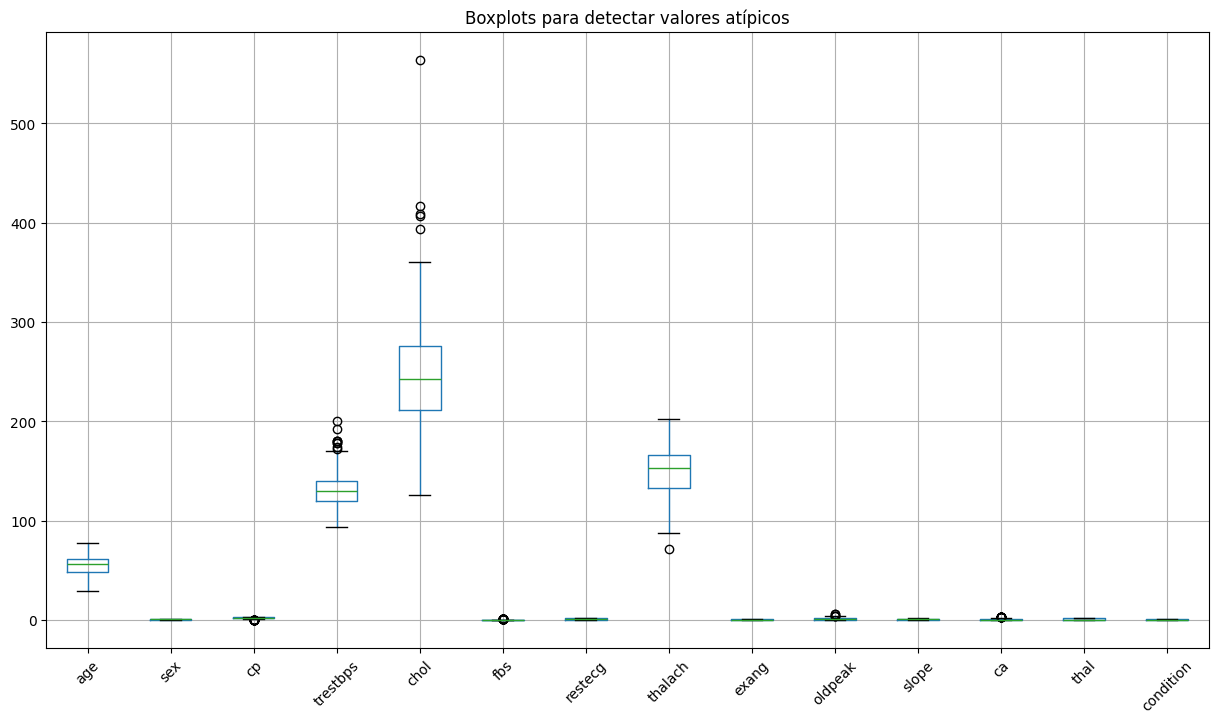

In [19]:
data_raw.boxplot(figsize=(15,8), rot=45)
plt.title("Boxplots para detectar valores atípicos")
plt.show()


Algunas variables como Presión arterial en reposo `trestbps` y colesterol `chol` presentan mas valores atípicos

La exploración inicial del dataset muestra  una distribución relativamente balanceada entre pacientes con y sin enfermedad cardíaca, lo que permite construir modelos sin necesidad de balancear clases. A través de la matriz de correlación, se identificaron varias variables con fuerte relación con la presencia de enfermedad cardíaca, destacándose thal, ca, oldpeak, exang, cp, slope y thalach (esta última con correlación negativa). Estas variables serán claves para el modelo de regresión logística. Además, no se encontraron valores faltantes, y algunas variables categóricas requieren transformación antes del modelado. Estos hallazgos permiten avanzar con confianza hacia el preprocesamiento y entrenamiento del modelo.


## 2. Preparación de los datos

De acuerdo a la observación inicial de los datos y a la documentación de la dat para el preprocesamiento de datos se realizará :
- Separar variables categóricas y numéricas: age, trestbps, chol, thalach, oldpeak

- Codificar variables categóricas: Estas variables, aunque están codificadas como enteros, deben tratarse como categóricas usando One-Hot Encoding para las variables categóricas con más de 2 valores (cp, restecg, slope, thal, ca) y dejando como están las binarias (sex, fbs, exang).

-  Separar features y target:La variable objetivo es condition.

- Dividir el dataset en entrenamiento y prueba: Usando un 80/20 split.

- Estandarizar las variables numéricas: Esto es importante para la regresión logística, ya que mejora la convergencia del modelo.




In [20]:
data = data_raw.copy()

In [21]:
#Variables numéricas y categóricas
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_categorical = ['sex', 'fbs', 'exang']
multi_categorical = ['cp', 'restecg', 'slope', 'thal', 'ca']

**Codificación**

In [23]:
data_encoded = pd.get_dummies(data, columns=multi_categorical, drop_first=True)


In [24]:
#  Separación variable objetivo
X = data_encoded.drop('condition', axis=1)
y = data_encoded['condition']

Se verifica el dataset

In [25]:
print(data_encoded.head())


   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  condition   cp_1  \
0   69    1       160   234    1      131      0      0.1          0  False   
1   69    0       140   239    0      151      0      1.8          0  False   
2   66    0       150   226    0      114      0      2.6          0  False   
3   65    1       138   282    1      174      0      1.4          1  False   
4   64    1       110   211    0      144      1      1.8          0  False   

   ...   cp_3  restecg_1  restecg_2  slope_1  slope_2  thal_1  thal_2   ca_1  \
0  ...  False      False       True     True    False   False   False   True   
1  ...  False      False      False    False    False   False   False  False   
2  ...  False      False      False    False     True   False   False  False   
3  ...  False      False       True     True    False   False   False   True   
4  ...  False      False       True     True    False   False   False  False   

    ca_2   ca_3  
0  False  False  
1   True

**Dividir en entrenamiento y prueba** Se divide los conjuntos de datos de test y train con una semilla random de 25

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25, stratify=y)

In [27]:
#  Estandarización de variables numéricas
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

## 3. Selección de características.

Inicialmente se usará  `SelectKBest` con chi-cuadrado `chi2` para evaluar la relevancia de las variables categóricas y `f_classif `para las numérica

In [28]:
from sklearn.feature_selection import SelectKBest, chi2

# chi2 solo funciona con valores positivos
# Revisando  que no haya negativos en X_train
X_train_chi2 = X_train.copy()
X_test_chi2 = X_test.copy()

X_train_chi2[X_train_chi2 < 0] = 0
X_test_chi2[X_test_chi2 < 0] = 0

# apicando SelectKBest
selector = SelectKBest(score_func=chi2, k='all')  # Puedes poner un número en lugar de 'all' para limitar
selector.fit(X_train_chi2, y_train)

# Resultado de los puntajes
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(feature_scores)


      Feature      Score
7     oldpeak  44.100835
10       cp_3  32.532133
6       exang  27.605050
16     thal_2  27.551021
5     thalach  23.641265
18       ca_2  18.980077
9        cp_2  14.380822
13    slope_1  13.563998
8        cp_1  11.573354
19       ca_3  11.173048
0         age   5.988126
17       ca_1   4.670268
2    trestbps   4.620296
1         sex   3.288299
12  restecg_2   2.593454
15     thal_1   2.396941
14    slope_2   1.580046
3        chol   1.075732
11  restecg_1   0.516270
4         fbs   0.219933


Las variables que parecen tener mayor relación con la presencia de enfermedad cardíaca son:

`oldpeak` (depresión del ST inducida por ejercicio)

`cp_3` (dolor de pecho asintomático)

`exang` (angina inducida por ejercicio)

`thal_2` (defecto reversible)

`thalach` (frecuencia cardiaca máxima)

`ca_2` (número de vasos coloreados)

`cp_2` (dolor no anginal)

Estas tienen puntajes significativamente más altos, lo que sugiere que aportan más información útil al modelo.

Como la regresión logística tiene regularización se puede usar todas las variables.

## 4. División en Train y test
La división se realizó en el preprocesamiento

## 5. Entrenar el modelo con ajuste de hiperparámetros.

Los parámetros que se ajustarán son:

- C: El inverso de la regularización, que controla el balance entre sobreajuste y subajuste. Valores más pequeños hacen el modelo más regularizado.

- penalty: Especifica el tipo de regularización ('l1' para Lasso, 'l2' para Ridge).

- max_iter: El número máximo de iteraciones que se realizarán para que el modelo se ajuste.

.

Entrenamiento y evaluación: Se entrena el modelo con los mejores parámetros y se evalúa su rendimiento en el conjunto de prueba con la métrica classification_report, que incluye precisión, recall y f1-score.




In [33]:

# Se define el modelo
model = LogisticRegression(solver='liblinear')

In [34]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Hiperparámetro C (inverso de la regularización)
    'penalty': ['l1', 'l2'],  # Tipo de regularización
    'max_iter': [100, 200, 300]  # Número de iteraciones máximas
}

GridSearchCV: Realiza la búsqueda en el espacio de los hiperparámetros con validación cruzada de KFold para dividir el conjunto de entrenamiento en 5 pliegues , utilizando precisión (accuracy) como métrica de evaluación

In [35]:
# Se define KFold con 5 pliegues
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#  GridSearchCV con KFold
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, n_jobs=-1, scoring='accuracy')

# Ajustar el modelo
grid_search.fit(X_train, y_train)

# Imprimir los mejores parámetros encontrados
print("Mejores parámetros:", grid_search.best_params_)


Mejores parámetros: {'C': 1, 'max_iter': 100, 'penalty': 'l1'}


Ahora se entrena el modelo con los mejores parámetros

In [36]:
# mejores parámetros
best_model = grid_search.best_estimator_

## 6. Evaluación del modelo

Se va medir el rendimiento del modelo con la métrica de accuarcy para el conjunto de prueba y tambien se quiere conocer el puntaje de la validación cruzada sobre los plieges para tener una idea de cómo el modelo se comporta en los diferentes pliegues.

**Predicciones**

In [37]:
# Predicciones en el set de prueba
y_pred = best_model.predict(X_test)

**Reporte de métricas**

In [42]:
print(classification_report(y_test, y_pred))

# precisión en el conjunto de prueba
accuracy = best_model.score(X_test, y_test)
print("Precisión en el conjunto de prueba:", accuracy)

#  puntaje de la validación cruzada sobre los pliegues:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Puntajes de validación cruzada: {cv_scores}')
print(f'Precisión media de validación cruzada: {cv_scores.mean()}')

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60

Precisión en el conjunto de prueba: 0.9166666666666666
Puntajes de validación cruzada: [0.75       0.75       0.93617021 0.85106383 0.72340426]
Precisión media de validación cruzada: 0.8021276595744681


El modelo tiene un buen desempeño en general, especialmente con un alto recall para la clase 0, lo que sugiere que está capturando bien los pacientes sin enfermedad cardíaca. Sin embargo, hay margen de mejora en el recall para la clase 1, que indica que algunos pacientes con enfermedad cardíaca podrían no ser identificados correctamente (aunque la precisión para esta clase es perfecta).

## 7. Visualización de los resultados

A continuación se observará los resultados con las metricas:
- Curva ROC (Receiver Operating Characteristic): Muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos. El área bajo la curva (AUC) es una medida del desempeño del modelo. Cuanto más cercano a 1, mejor es el modelo.

- Curva de Precisión-Recall: Muestra la relación entre precisión y recall. Es útil cuando hay clases desbalanceadas, como en este caso. La curva nos ayuda a ver cómo cambia la precisión a medida que se ajusta el recall.

- Matriz de Confusión: Una visualización de cuántos casos fueron correctamente o incorrectamente clasificados. Los valores en la diagonal representan los casos correctamente clasificados.


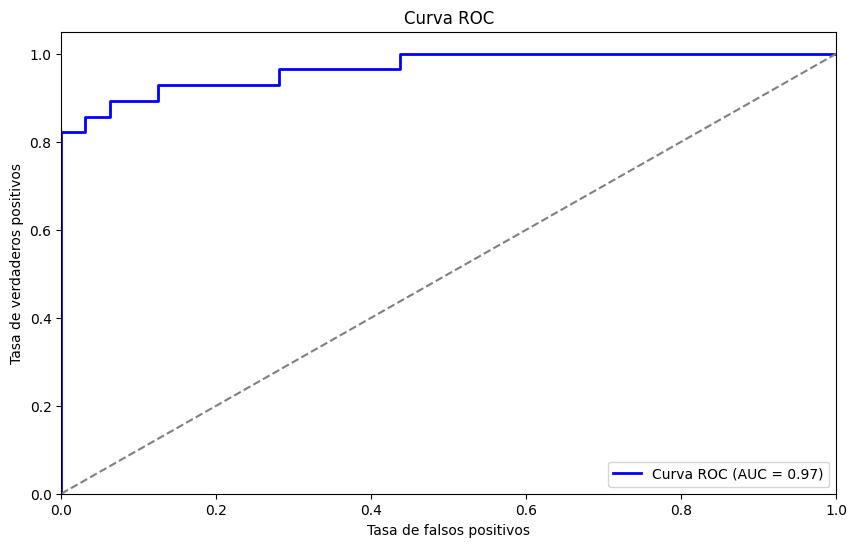

In [46]:
# Curva ROC

y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase 1

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

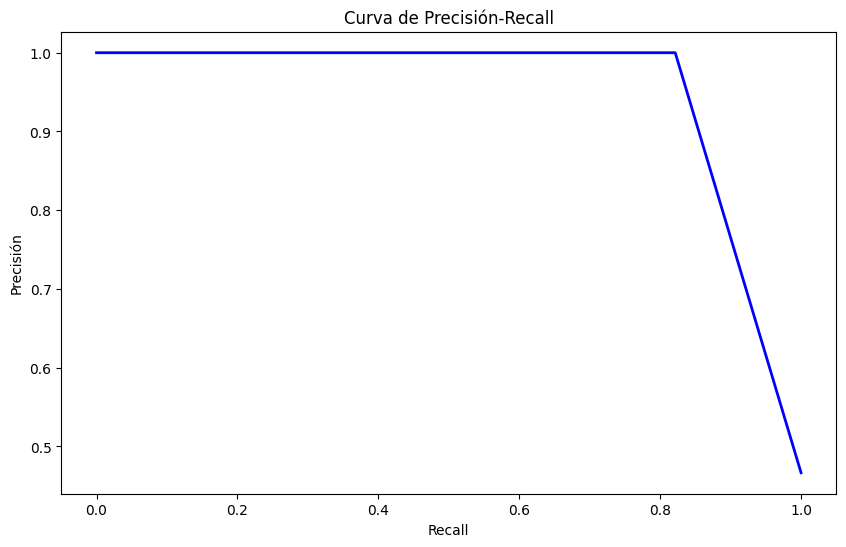

In [57]:
# Curva de precisión-recall
precision, recall, _ = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva de Precisión-Recall')
plt.show()

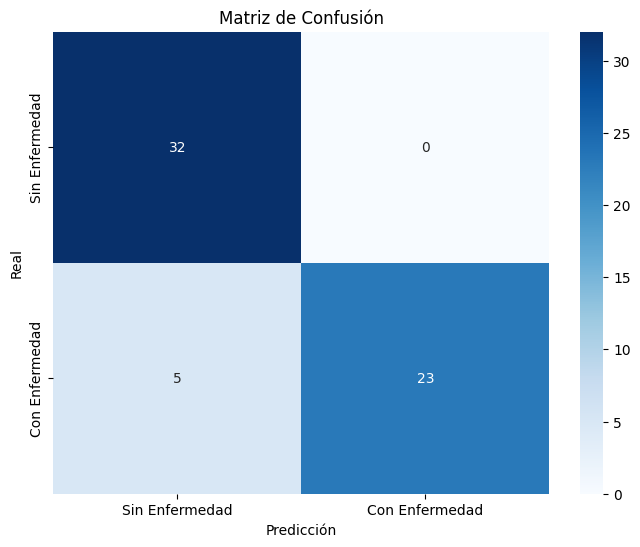

In [51]:
#  Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sin Enfermedad', 'Con Enfermedad'], yticklabels=['Sin Enfermedad', 'Con Enfermedad'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


**Variables importantes** Se quiere conocer cuales son las variables mas importantes en el modelo,  o sea las características que más influyen en el modelo observando los coeficientes del modelo de regresión logística

In [60]:
coef = pd.DataFrame(best_model.coef_.flatten(), index=X_train.columns, columns=['Coeficiente'])
coef = coef.sort_values(by='Coeficiente', ascending=False)

# Mostrar las 10 variables más importantes
print(coef.head(10))

         Coeficiente
ca_2        1.855516
cp_3        1.229043
ca_3        1.155096
ca_1        1.153354
thal_2      1.002051
sex         0.655915
oldpeak     0.588411
exang       0.559446
slope_1     0.442159
cp_1        0.272121


## 8. Analisis de Resultados:

**Precisión:** En el conjunto de prueba, obtenemos una precisión de aproximadamente 91.67%, lo que significa que el modelo está haciendo predicciones correctas en alrededor del 92% de los casos.

**Recall:** El recall de la clase 0 (sin enfermedad) es del 100%, lo que indica que el modelo ha identificado todos los casos sin enfermedad correctamente. Sin embargo, el recall de la clase 1 (con enfermedad) es del 82%, lo que sugiere que el modelo ha fallado en identificar algunos pacientes con enfermedad cardíaca.

**F1-Score:** El F1-Score es una métrica que equilibra la precisión y el recall. El F1-Score para la clase 0 es de 0.93, mientras que para la clase 1 es de 0.90. Esto muestra que el modelo tiene un buen equilibrio entre precisión y recall, aunque aún podría mejorarse en identificar todos los pacientes con enfermedad.

**Validación Cruzada:** La precisión media de la validación cruzada es de 80.21%, lo que indica que el modelo es razonablemente robusto y consistente a través de diferentes particiones de los datos. Sin embargo, hay variabilidad en los puntajes de validación cruzada, lo que sugiere que el modelo podría beneficiarse de un ajuste de hiperparámetros o de una mayor optimización.

**Coeficientes** ca_2, cp_3, ca_3, ca_1 son las variables más influyentes, todas con coeficientes positivos. Esto indica que un valor más alto de estas características aumenta la probabilidad de que el modelo prediga la presencia de enfermedad cardíaca.

thal_2, sex, oldpeak, exang, slope_1 también tienen coeficientes positivos, lo que implica que influyen en la probabilidad de enfermedad, aunque en menor medida en comparación con las anteriores.